In [1]:
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import numpy as np
from sklearn.neural_network import MLPRegressor

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data,housing.target,random_state=42,test_size=0.2)

The first hidden layer’s input size (i.e., the number of rows in its weights matrix) and the output layer’s output size (i.e., the number of columns in its weights matrix) will adjust automatically to the dimensionality of the inputs and targets, respectively, when training starts. The model uses the ReLU activation function in all hidden layers, and no activation function at all on the output layer. We also set verbose=True to get details on the model’s progress during training:

In [4]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50],verbose=True,random_state=42,early_stopping=True)

Since neural nets can have a lot of parameters, they have a tendency to overfit the training set. To reduce this risk, one option is to use early stopping  when we set early_stopping=True, the MLPRegressor class automatically sets aside 10% of the training data and uses it to evaluate the model at each epoch (you can adjust the validation set’s size by setting validation_fraction). If the validation score stops improving for 10 epochs, training automatically stops (you can tweak this number of epochs by setting n_iter_no_change).

In [5]:
pipeline = Pipeline([("Scaler",StandardScaler()),("Regressor",mlp_reg)])
pipeline.fit(X_train,y_train)

Iteration 1, loss = 0.76415490
Validation score: 0.520913
Iteration 2, loss = 0.25585925
Validation score: 0.618487
Iteration 3, loss = 0.21339026
Validation score: 0.653806
Iteration 4, loss = 0.19738261
Validation score: 0.672825
Iteration 5, loss = 0.18617398
Validation score: 0.686910
Iteration 6, loss = 0.17934196
Validation score: 0.693797
Iteration 7, loss = 0.17218261
Validation score: 0.712043
Iteration 8, loss = 0.16584184
Validation score: 0.716656
Iteration 9, loss = 0.16227113
Validation score: 0.726708
Iteration 10, loss = 0.15878225
Validation score: 0.733606
Iteration 11, loss = 0.15568816
Validation score: 0.735459
Iteration 12, loss = 0.15481375
Validation score: 0.740578
Iteration 13, loss = 0.15013915
Validation score: 0.747015
Iteration 14, loss = 0.14900205
Validation score: 0.746490
Iteration 15, loss = 0.15054243
Validation score: 0.747185
Iteration 16, loss = 0.14701848
Validation score: 0.743242
Iteration 17, loss = 0.14807400
Validation score: 0.752939
Iterat

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Scaler', ...), ('Regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[50, 50, ...]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_p

In [6]:
mlp_reg.best_validation_score_

0.7846984503757974

$R^2$ score for the regressor

In [10]:
y_predictions = pipeline.predict(X_test)
rsme = root_mean_squared_error(y_test,y_pred=y_predictions)
rsme

0.5207629610958802

We get a test RMSE of about 0.52, which is comparable to what you would get with a random forest classifier. 

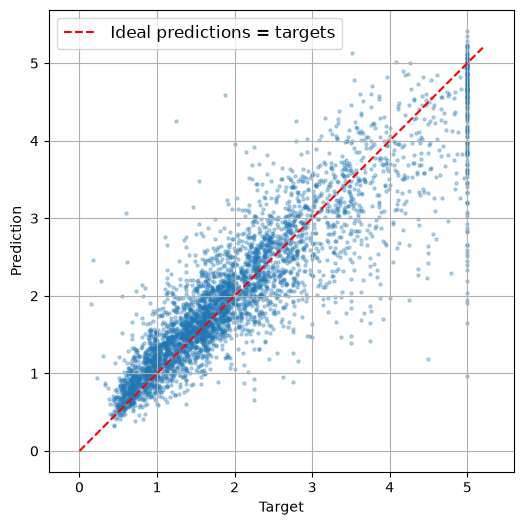

In [28]:
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_predictions, s=5, alpha=0.3)
plt.plot([0, 5.2], [0, 5.2], color='red', linestyle='--',
         label="Ideal predictions = targets")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.legend(fontsize=12)
plt.grid()

plt.show()